# CH 6 : Factor 3 — Degree of Rule Correlation

## Objectif pédagogique

Ce notebook illustre un point central de l’EBTA de David Aronson :

> Plus les règles testées sont **corrélées**, plus le **biais de minage de données** est compressé.

L’idée n’est pas seulement de compter le nombre de règles testées sur le papier.

L’idée est de mesurer combien de **vraies tentatives indépendantes** ont été offertes au hasard.

Une optimisation de paramètres très proche, comme une moyenne mobile 20/50 contre 21/50, crée souvent des règles très similaires.

À l’inverse, tester des familles d’indicateurs très différentes crée davantage de chances de sélectionner un faux champion.

## Intuition EBTA

Dans un backtest, on peut observer une performance positive pour deux raisons :

- la règle possède un **pouvoir prédictif réel** ;
- la règle a simplement bénéficié d’une **chance d’échantillon**.

Quand on teste beaucoup de règles, puis qu’on sélectionne uniquement la meilleure, on donne au hasard beaucoup d’occasions de produire un résultat extrême.

Mais toutes les règles ne donnent pas au hasard le même nombre d’occasions.

Si les règles sont presque identiques, leurs performances montent et descendent ensemble.

Elles ne représentent donc pas $N$ essais réellement indépendants.

> Le vrai danger n’est pas seulement le nombre de règles testées.  
> Le vrai danger est le nombre de **directions indépendantes** dans lesquelles on a cherché un miracle statistique.

## Formule mentale : $N$ papier vs $N_{\text{effectif}}$

On peut écrire l’idée ainsi :

$$
N_{\text{effectif}} \leq N_{\text{papier}}
$$

où :

- $N_{\text{papier}}$ est le nombre total de règles affichées dans le backtest ;
- $N_{\text{effectif}}$ est le nombre approximatif de règles statistiquement indépendantes.

Quand la corrélation moyenne entre les règles augmente, $N_{\text{effectif}}$ diminue.

Quand la corrélation moyenne baisse, $N_{\text{effectif}}$ augmente.

La conséquence directe est :

$$
\text{Corrélation élevée} \Rightarrow \text{moins de biais de sélection}
$$

$$
\text{Corrélation faible} \Rightarrow \text{plus de biais de sélection}
$$

## Setup Python

Nous allons simuler des performances de règles de trading sous l’hypothèse nulle.

Cela signifie que les règles n’ont **aucun edge réel**.

Leur performance moyenne attendue est donc égale à zéro.

Si un champion apparaît, il ne peut venir que du hasard et du processus de sélection.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## Fonction de simulation

Nous allons générer plusieurs règles de trading artificielles.

Chaque règle possède une série de rendements.

Toutes les règles ont une espérance vraie de zéro :

$$
E[R_i] = 0
$$

Le paramètre important est la corrélation $\rho$ entre les règles.

Pour créer cette corrélation, chaque règle est composée :

- d’un facteur commun partagé par toutes les règles ;
- d’un bruit spécifique propre à chaque règle.

$$
R_{t,i} = \sqrt{\rho} \cdot F_t + \sqrt{1 - \rho} \cdot \epsilon_{t,i}
$$

où :

- $F_t$ est le facteur commun ;
- $\epsilon_{t,i}$ est le bruit spécifique de la règle $i$ ;
- $\rho$ contrôle la similarité entre les règles.

In [2]:
def simulate_correlated_rule_returns(
    n_observations=252,
    n_rules=256,
    rho=0.0,
    sigma=0.01,
    seed=None
):
    """
    Simule les rendements de plusieurs règles sans edge réel,
    avec une corrélation moyenne contrôlée entre les règles.

    Parameters
    ----------
    n_observations : int
        Nombre d'observations par règle.
    n_rules : int
        Nombre de règles testées.
    rho : float
        Corrélation commune approximative entre les règles.
    sigma : float
        Volatilité des rendements.
    seed : int or None
        Graine aléatoire.

    Returns
    -------
    pd.DataFrame
        Rendements simulés des règles.
    """
    rng = np.random.default_rng(seed)

    common_factor = rng.normal(0, sigma, size=(n_observations, 1))
    specific_noise = rng.normal(0, sigma, size=(n_observations, n_rules))

    returns = np.sqrt(rho) * common_factor + np.sqrt(1 - rho) * specific_noise

    columns = [f"rule_{i+1:03d}" for i in range(n_rules)]
    return pd.DataFrame(returns, columns=columns)

## Exemple 1 — Règles indépendantes

Commençons avec $\rho = 0$.

Les règles sont décorrélées.

Chaque règle donne au hasard une nouvelle chance indépendante de produire un bon résultat.

In [3]:
returns_independent = simulate_correlated_rule_returns(
    n_observations=252,
    n_rules=256,
    rho=0.0,
    seed=1
)

rule_mean_returns = returns_independent.mean()
best_rule = rule_mean_returns.idxmax()

print(f"Meilleure règle sélectionnée : {best_rule}")
print(f"Performance moyenne observée : {rule_mean_returns.max():.4%}")
print(f"Performance moyenne médiane : {rule_mean_returns.median():.4%}")
print(f"Performance vraie attendue : 0.0000%")

rule_mean_returns.sort_values(ascending=False).head(10)

Meilleure règle sélectionnée : rule_184
Performance moyenne observée : 0.1284%
Performance moyenne médiane : -0.0040%
Performance vraie attendue : 0.0000%


rule_184    0.001284
rule_077    0.001258
rule_227    0.001233
rule_162    0.001228
rule_065    0.001193
rule_062    0.001171
rule_129    0.001166
rule_072    0.001142
rule_118    0.001077
rule_167    0.001046
dtype: float64

## Visualisation du piège

La meilleure règle semble avoir une performance positive.

Mais dans cette simulation, nous savons que toutes les règles ont une espérance vraie de zéro.

Le champion est donc un **mirage statistique**.

Il a été sélectionné parce qu’il était le plus chanceux parmi 256 candidats.

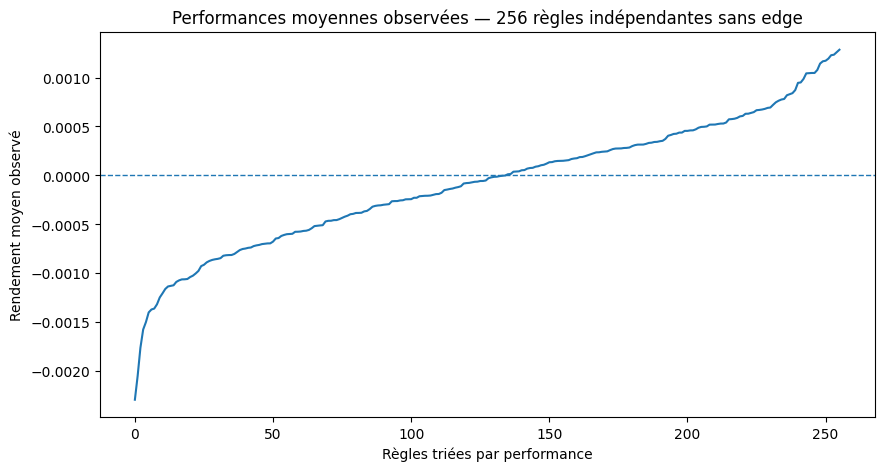

In [4]:
plt.figure(figsize=(10, 5))
rule_mean_returns.sort_values().reset_index(drop=True).plot()
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Performances moyennes observées — 256 règles indépendantes sans edge")
plt.xlabel("Règles triées par performance")
plt.ylabel("Rendement moyen observé")
plt.show()

## Exemple 2 — Règles fortement corrélées

Maintenant, testons le même nombre de règles, mais avec une forte corrélation :

$$
\rho = 0.90
$$

Sur le papier, nous testons toujours 256 règles.

Mais statistiquement, elles se ressemblent beaucoup.

Leur nombre effectif est donc bien plus faible.

In [5]:
returns_correlated = simulate_correlated_rule_returns(
    n_observations=252,
    n_rules=256,
    rho=0.90,
    seed=1
)

rule_mean_returns_corr = returns_correlated.mean()
best_rule_corr = rule_mean_returns_corr.idxmax()

print(f"Meilleure règle sélectionnée : {best_rule_corr}")
print(f"Performance moyenne observée : {rule_mean_returns_corr.max():.4%}")
print(f"Performance moyenne médiane : {rule_mean_returns_corr.median():.4%}")
print(f"Performance vraie attendue : 0.0000%")

rule_mean_returns_corr.sort_values(ascending=False).head(10)

Meilleure règle sélectionnée : rule_184
Performance moyenne observée : -0.0536%
Performance moyenne médiane : -0.0954%
Performance vraie attendue : 0.0000%


rule_184   -0.000536
rule_077   -0.000544
rule_227   -0.000552
rule_162   -0.000553
rule_065   -0.000564
rule_062   -0.000571
rule_129   -0.000573
rule_072   -0.000580
rule_118   -0.000601
rule_167   -0.000611
dtype: float64

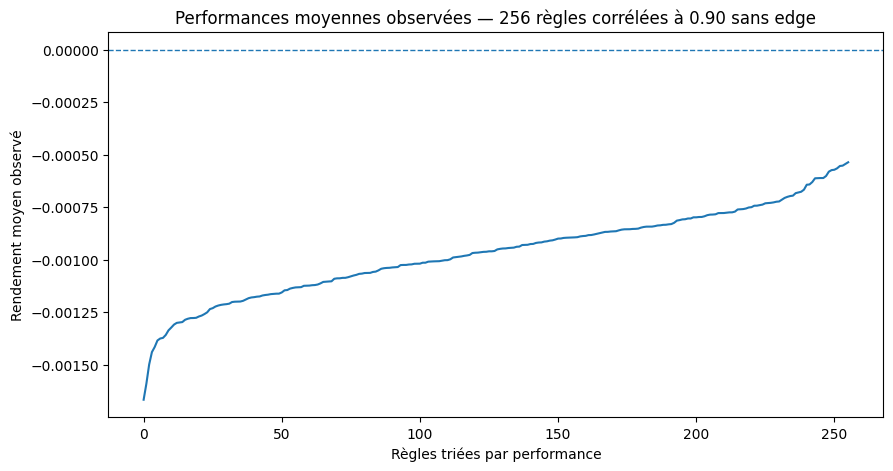

In [6]:
plt.figure(figsize=(10, 5))
rule_mean_returns_corr.sort_values().reset_index(drop=True).plot()
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Performances moyennes observées — 256 règles corrélées à 0.90 sans edge")
plt.xlabel("Règles triées par performance")
plt.ylabel("Rendement moyen observé")
plt.show()

## Expérience Monte Carlo

Une seule simulation peut être trompeuse.

Nous allons donc répéter l’expérience plusieurs fois.

À chaque répétition :

1. on génère 256 règles sans edge ;
2. on calcule la performance moyenne de chaque règle ;
3. on sélectionne la meilleure ;
4. on enregistre la performance du champion.

Ce champion représente le résultat que le data-miner aurait présenté comme “la meilleure stratégie”.

In [7]:
def monte_carlo_best_rule_bias(
    n_experiments=1000,
    n_observations=252,
    n_rules=256,
    rho=0.0,
    sigma=0.01,
    seed=123
):
    rng = np.random.default_rng(seed)
    best_performances = []

    for _ in range(n_experiments):
        experiment_seed = rng.integers(0, 1_000_000_000)

        returns = simulate_correlated_rule_returns(
            n_observations=n_observations,
            n_rules=n_rules,
            rho=rho,
            sigma=sigma,
            seed=experiment_seed
        )

        mean_returns = returns.mean()
        best_performances.append(mean_returns.max())

    return np.array(best_performances)

In [8]:
rho_values = [0.0, 0.25, 0.50, 0.75, 0.90, 0.99]

results = {}

for rho in rho_values:
    results[rho] = monte_carlo_best_rule_bias(
        n_experiments=1000,
        n_observations=252,
        n_rules=256,
        rho=rho,
        seed=42
    )

summary = pd.DataFrame({
    "correlation_rho": rho_values,
    "average_best_rule": [results[rho].mean() for rho in rho_values],
    "median_best_rule": [np.median(results[rho]) for rho in rho_values],
    "p95_best_rule": [np.percentile(results[rho], 95) for rho in rho_values]
})

summary

,correlation_rho,average_best_rule,median_best_rule,p95_best_rule
0,0.00,0.001787,0.001761,0.002253
1,0.25,0.001554,0.001571,0.002172
2,0.50,0.001272,0.001286,0.002065
3,0.75,0.000904,0.000916,0.001806
4,0.90,0.000576,0.000578,0.001533
5,0.99,0.000190,0.000194,0.001183


## Résultat central

Le tableau montre la performance moyenne du meilleur candidat sous l’hypothèse où aucune règle n’a d’edge.

Donc cette performance est du **biais de minage pur**.

Plus $\rho$ augmente, plus le meilleur résultat sélectionné diminue.

Pourquoi ?

Parce que le data-miner n’explore plus 256 chemins vraiment différents.

Il explore 256 variantes d’une même idée.

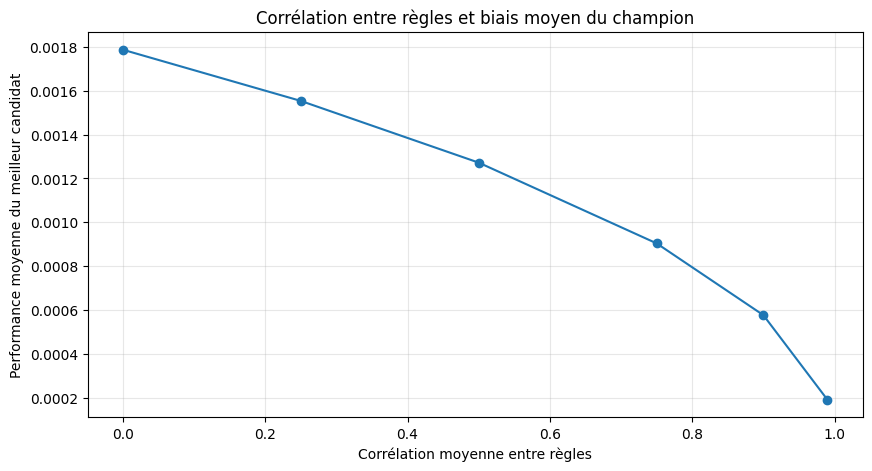

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(summary["correlation_rho"], summary["average_best_rule"], marker="o")
plt.title("Corrélation entre règles et biais moyen du champion")
plt.xlabel("Corrélation moyenne entre règles")
plt.ylabel("Performance moyenne du meilleur candidat")
plt.grid(True, alpha=0.3)
plt.show()

## Distribution du champion selon la corrélation

Regardons maintenant la distribution complète du meilleur résultat.

Lorsque les règles sont indépendantes, le meilleur candidat a beaucoup plus de chances d’être extrême.

Lorsque les règles sont très corrélées, le champion est moins spectaculaire.

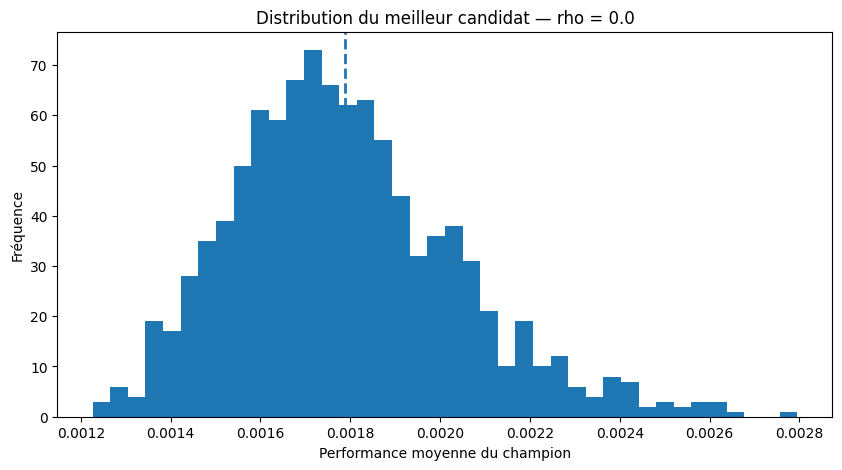

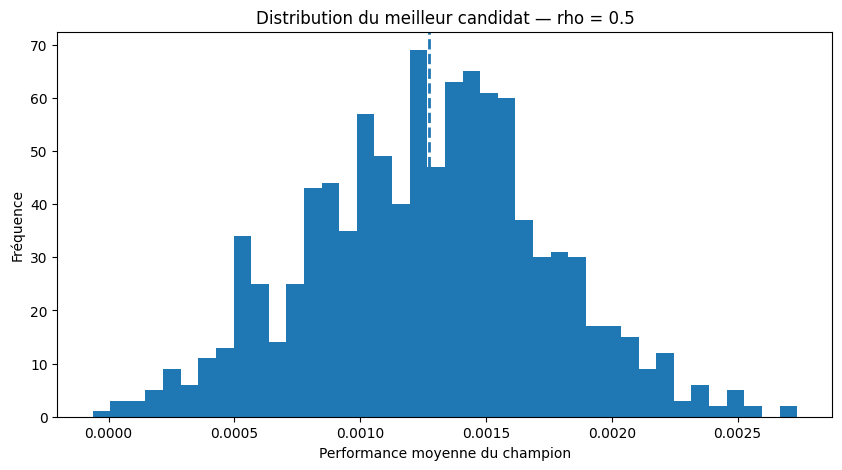

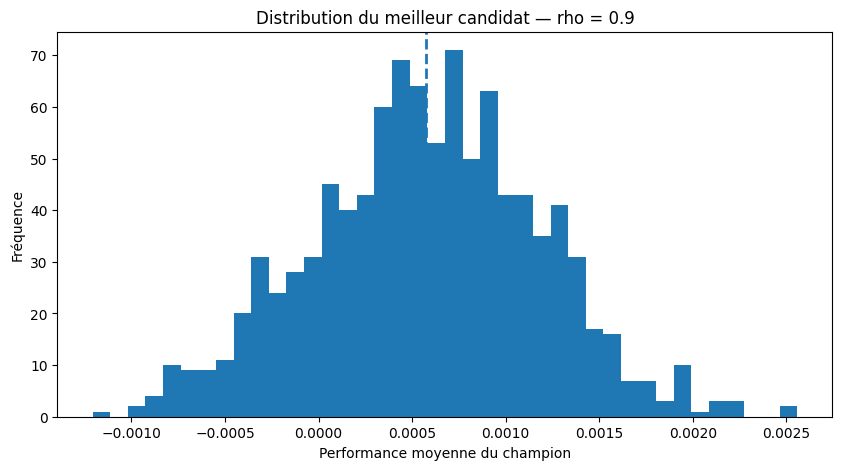

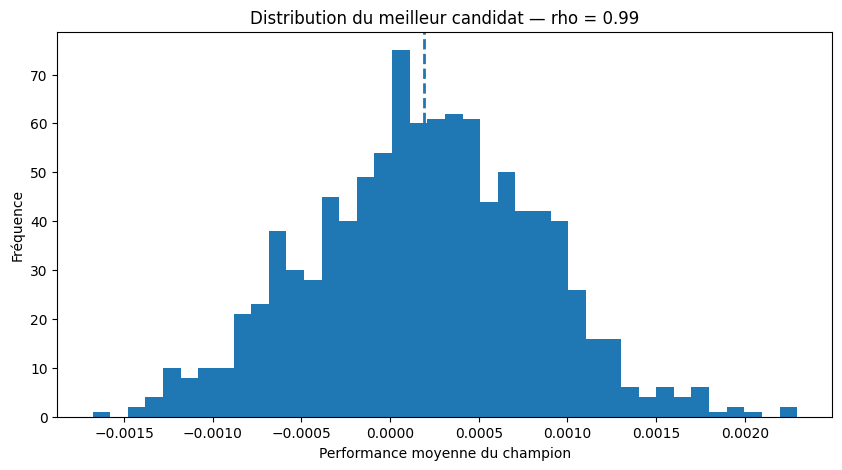

In [10]:
for rho in [0.0, 0.50, 0.90, 0.99]:
    plt.figure(figsize=(10, 5))
    plt.hist(results[rho], bins=40)
    plt.axvline(results[rho].mean(), linestyle="--", linewidth=2)
    plt.title(f"Distribution du meilleur candidat — rho = {rho}")
    plt.xlabel("Performance moyenne du champion")
    plt.ylabel("Fréquence")
    plt.show()

## Approximation simple du nombre effectif de règles

Il existe plusieurs méthodes plus avancées pour estimer un nombre effectif de tests.

Pour l’intuition pédagogique, on peut utiliser une approximation simple :

$$
N_{\text{effectif}} \approx 1 + (N - 1)(1 - \rho)
$$

Cette formule n’est pas une loi universelle.

Elle sert seulement à visualiser l’idée suivante :

- si $\rho = 0$, alors $N_{\text{effectif}} \approx N$ ;
- si $\rho = 1$, alors $N_{\text{effectif}} \approx 1$ ;
- entre les deux, la corrélation compresse le nombre réel de paris indépendants.

> En EBTA, ce qui compte n’est pas seulement combien de règles tu as testées.  
> Ce qui compte est combien de fois tu as laissé le hasard tenter une nouvelle combinaison réellement différente.

In [11]:
n_rules = 256

n_effective = pd.DataFrame({
    "rho": rho_values,
    "n_paper": n_rules,
    "n_effective_approx": [1 + (n_rules - 1) * (1 - rho) for rho in rho_values]
})

n_effective

,rho,n_paper,n_effective_approx
0,0.00,256,256.00
1,0.25,256,192.25
2,0.50,256,128.50
3,0.75,256,64.75
4,0.90,256,26.50
5,0.99,256,3.55


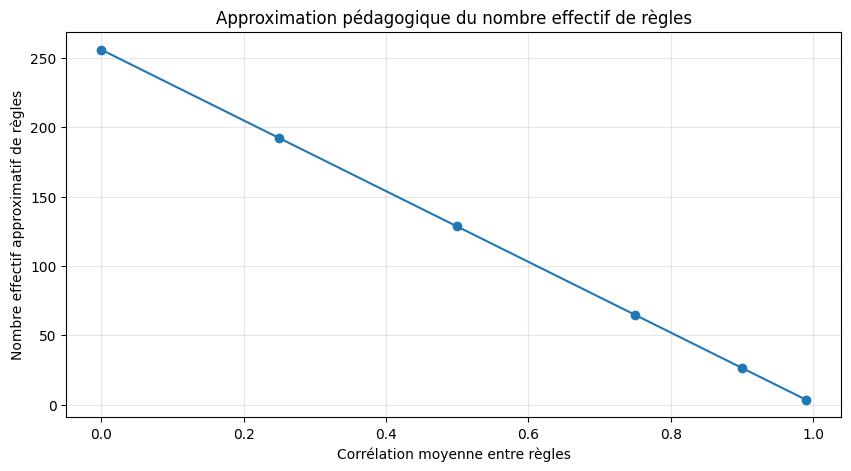

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(n_effective["rho"], n_effective["n_effective_approx"], marker="o")
plt.title("Approximation pédagogique du nombre effectif de règles")
plt.xlabel("Corrélation moyenne entre règles")
plt.ylabel("Nombre effectif approximatif de règles")
plt.grid(True, alpha=0.3)
plt.show()

## Application trading : optimisation vs recherche large

Prenons deux situations.

### Situation A — Optimisation de paramètres

Tu testes :

- moyenne mobile 20/50 ;
- moyenne mobile 21/50 ;
- moyenne mobile 22/50 ;
- moyenne mobile 23/50.

Ces règles seront souvent fortement corrélées.

Elles traduisent la même logique de marché.

Le data-mining existe, mais il est partiellement compressé.

### Situation B — Recherche d’idées décorrélées

Tu testes :

- croisement de moyennes mobiles ;
- RSI ;
- breakout ;
- pattern chandeliers ;
- VWAP ;
- Bollinger Bands ;
- seasonality ;
- order flow ;
- news sentiment.

Ces règles peuvent être beaucoup moins corrélées.

Tu multiplies les angles de recherche.

Le risque de sélectionner un faux champion augmente fortement.

## Exemple concret : matrice de corrélation des règles

Dans un vrai workflow EBTA, tu peux calculer la corrélation entre les rendements de tes règles.

L’objectif n’est pas seulement de regarder la performance individuelle.

L’objectif est de savoir si ton univers de règles contient beaucoup de copies d’une même idée ou beaucoup d’idées réellement différentes.

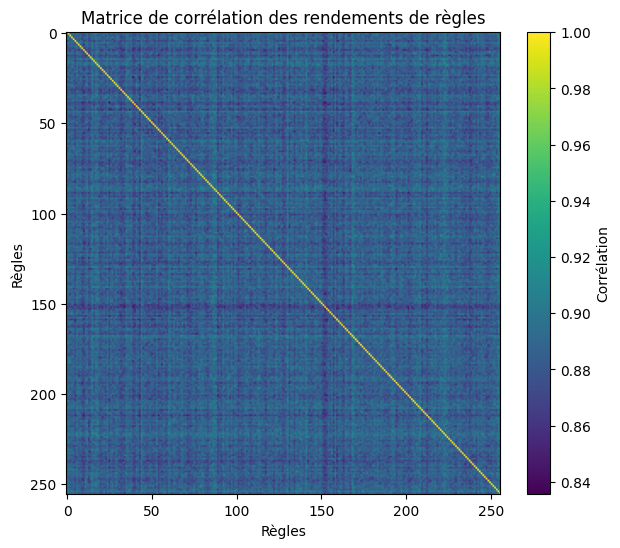

Corrélation moyenne hors diagonale : 0.88


In [13]:
# Exemple avec les règles fortement corrélées simulées
corr_matrix = returns_correlated.corr()

plt.figure(figsize=(7, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Corrélation")
plt.title("Matrice de corrélation des rendements de règles")
plt.xlabel("Règles")
plt.ylabel("Règles")
plt.show()

print(f"Corrélation moyenne hors diagonale : {(corr_matrix.values[np.triu_indices_from(corr_matrix, k=1)]).mean():.2f}")

## Checklist EBTA pour tes backtests

Avant de croire au meilleur résultat d’une recherche de stratégies, pose ces questions :

| Question | Pourquoi c’est important |
|---|---|
| Combien de règles ai-je testées ? | Plus $N$ augmente, plus le hasard a d’occasions de produire un champion. |
| Les règles sont-elles similaires ou différentes ? | La corrélation réduit ou augmente le nombre effectif de tests. |
| Ai-je optimisé une seule logique ou testé beaucoup de familles ? | Les familles décorrélées sont plus dangereuses statistiquement. |
| Ai-je mesuré la corrélation des rendements de règles ? | Cela quantifie la diversité réelle de mon univers de recherche. |
| Ai-je corrigé le biais de sélection ? | White’s Reality Check ou méthodes proches deviennent nécessaires. |

## L’Eurêka final

> La corrélation entre règles est le frein naturel du data-mining bias.

Quand les règles sont très corrélées, le data-miner croit avoir testé beaucoup d’idées, mais statistiquement il a surtout testé plusieurs copies d’une même idée.

Quand les règles sont décorrélées, chaque nouvelle règle offre au hasard une nouvelle chance de produire un faux miracle.

Le danger maximal apparaît donc quand on teste beaucoup de règles **différentes**, puis qu’on présente uniquement la meilleure comme si elle avait été découverte proprement.

## Résumé ultra-simple

- **Haute corrélation** = règles similaires = moins de tentatives indépendantes = moins de biais.
- **Faible corrélation** = règles différentes = plus de tentatives indépendantes = plus de biais.
- L’optimisation de paramètres est souvent moins dangereuse que la recherche large d’indicateurs hétérogènes.
- Mais même une corrélation modérée ne supprime pas le problème.
- Le vrai standard EBTA consiste à corriger statistiquement le processus de sélection.

## Annexe — Source originale fournie

Le texte ci-dessous est la source brute fournie pour générer ce notebook.

### **CH 6 : FACTOR 3 - DEGREE OF RULE CORRELATION**

Cette section analyse comment la similitude entre les règles testées (leur corrélation) influence l'ampleur du biais de minage de données. C'est un facteur déterminant pour comprendre la différence de risque entre l'optimisation de paramètres et la recherche de règles décorrélées.

#### **Idées clés :**
*   **Relation Inverse :** Plus la corrélation entre les rendements des règles est forte, plus le biais de minage de données est faible.
*   **Nombre "Effectif" de Règles :** La corrélation réduit le nombre réel de tentatives indépendantes offertes au hasard ; des règles très corrélées agissent statistiquement comme une seule et même règle.
*   **Optimisation vs Diversité :** L'optimisation de paramètres (ex: tester une moyenne mobile de 20 jours vs 21 jours) génère une forte corrélation et donc moins de biais que le test d'indicateurs totalement différents.
*   **Le Danger de l'Indépendance :** Tester des règles décorrélées (statistiquement indépendantes) maximise les chances qu'une règle "fit" le bruit du marché par pur accident,.

#### **Référence :**
*Factor 3: Degree of Rule Correlation*, Chapitre 6, pages 301 à 303.

#### **Citation Directe :**
« The stronger the correlation between the rules tested, the smaller will be the magnitude of the bias. Conversely, the lower the correlation... between rules returns, the larger will be the data-mining bias. » (Page 301).

---

#### **Vision Macro :**
L'enjeu est de mesurer l'originalité statistique de chaque test. David Aronson explique que le biais de minage ne dépend pas seulement du nombre de règles sur le papier ($N$), mais de leur "diversité logique". Si vous testez 1 000 variantes d'une même idée, le risque de tomber sur de l'or par erreur est limité car toutes les variantes échoueront ou réussiront ensemble. En revanche, si vous testez 1 000 idées radicalement différentes, vous multipliez les zones de recherche, ce qui augmente massivement la probabilité qu'une de ces idées finisse par ressembler à un profit par pur hasard.

---

#### **Vision Micro :**
Le mécanisme de la corrélation agit sur le "pouvoir de sélection" du minage :

1.  **Le cas limite (Corrélation = 1.0) :** Si toutes les règles sont identiques, vous n'avez fait qu'un seul test. Le biais est de zéro car il n'y a pas de sélection du maximum possible.
2.  **La réduction du "N effectif" :** Des règles fortement corrélées (ex: 0.90) réduisent le nombre effectif de règles testées. Statistiquement, chercher parmi 256 règles corrélées à 0.90 revient à chercher parmi un très petit nombre de règles indépendantes.
3.  **L'impact sur l'espérance de gain (Figure 6.55) :** Plus la corrélation est élevée, plus le rendement attendu du "champion" est faible. Pourquoi ? Parce qu'une corrélation élevée signifie moins de "recherche réelle" et donc moins d'opportunités de découvrir une règle supérieure (ou un coup de chance extrême).
4.  **Le seuil critique (Figure 6.36) :** L'expérience montre que le biais reste élevé tant que la corrélation n'approche pas des niveaux très hauts (proches de 1.0). Cela signifie que même une corrélation modérée ne protège pas totalement contre le biais,.

---

#### **Résumé Simplifié :**
Tester 100 fois la même recette avec un gramme de sel de différence, c'est tester une seule recette (fortement corrélé, peu de biais). Tester 100 recettes de pays différents, c'est multiplier les chances d'en trouver une qui te plaît par pur hasard (décorrélé, gros biais). En trading, optimiser une moyenne mobile est moins risqué statistiquement que de tester 50 indicateurs différents,.

---

#### **Exemples du livre pour mieux comprendre :**
*   **Les moyennes mobiles duales :** Aronson cite le cas d'un croisement de moyennes mobiles. Optimiser les paramètres 26/55 jours versus 27/55 jours produit des résultats extrêmement corrélés. Ici, le biais de minage est "compressé" par cette similitude.
*   **L'expérience des 256 ATR :** Il montre qu'avec une corrélation de 0.9, le gain attendu du meilleur candidat n'est que de +1,4 %, soit le même que celui d'une règle prise au hasard. Avec une corrélation de 0.0 (indépendance totale), le meilleur candidat affiche +4 %, prouvant que le minage a "ratissé" plus large pour trouver un maximum.

---

#### **Actions Concrètes :**
*   **Privilégier l'optimisation de paramètres :** Si vous devez chercher une règle, il est statistiquement plus "sûr" de rester sur une seule forme logique et d'en varier les paramètres que de sauter d'un indicateur à l'autre.
*   **Calculer la corrélation des signaux :** Avant de valider une sélection de règles, vérifiez si leurs historiques de trades se ressemblent. Si elles sont décorrélées, soyez deux fois plus exigeant sur le profit minimum requis.
*   **Ajuster le White's Reality Check :** Assurez-vous que votre test de significativité prend en compte la structure de corrélation (ce que fait le WRC) pour ne pas être indûment pénalisé ou trompé.

---

#### **À retenir absolument :**
*   **Haute Corrélation = Moins de Biais**.
*   **Indépendance = Danger de Mirage**.
*   Optimiser les paramètres d'une règle est **moins "biaisant"** que tester des indicateurs variés.
*   La corrélation **réduit le nombre effectif** de règles testées.
*   Le biais ne chute drastiquement que lorsque la corrélation est **très proche de 1.0**.

J'ai terminé l'analyse du facteur de corrélation des règles selon le protocole EBTA.